# BSPF 1D Viscous Burgers Solver

This notebook turns the legacy `fig3_data.py` workflow into a compact package-level example.

We solve the viscous Burgers equation

$$
u_t + u u_x = \nu u_{xx}
$$

with a method-of-lines discretization: BSPF provides the first and second spatial derivatives, and the package fixed-step RK4 integrator advances the solution in time.

## Environment Setup

The next cell makes the notebook runnable directly from the repository checkout without requiring an editable install first.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((parent for parent in (cwd, *cwd.parents) if (parent / "pyproject.toml").exists()), cwd)
SRC_ROOT = REPO_ROOT / "src"

for candidate in (SRC_ROOT, REPO_ROOT):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

REPO_ROOT

PosixPath('/Users/moulin/Workspace/pybspf')

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

from pybspf import BSPF1D

## Manufactured Solution

We reuse the smooth step profile from the legacy script so the notebook has an exact solution for initialization, boundary values, and error measurement.

The exact solution used throughout this example is

$$
u(x,t) = \frac{\alpha + \beta + (\beta - \alpha) \exp\!\left(\tfrac{\alpha}{\nu}(x - \beta t - \gamma)\right)}{1 + \exp\!\left(\tfrac{\alpha}{\nu}(x - \beta t - \gamma)\right)}
$$

with default parameters $\alpha = 0.4$, $\beta = 0.6$, and $\gamma = \pi$. We use this same expression for the initial condition $u(x,0)$, for the Dirichlet boundary values during time integration, and for the final error comparison.

In [3]:
def smooth_step_solution(
    x: np.ndarray,
    t: float | np.ndarray,
    nu: float,
    alpha: float = 0.4,
    beta: float = 0.6,
    gamma: float = np.pi,
) -> np.ndarray:
    t_array = np.atleast_1d(t)
    eta = (alpha / nu) * (x[None, :] - beta * t_array[:, None] - gamma)
    u = (alpha + beta + (beta - alpha) * np.exp(eta)) / (1.0 + np.exp(eta))
    return u.squeeze()


def relative_linf_error(approx: np.ndarray, exact: np.ndarray) -> float:
    return float(np.max(np.abs(approx - exact)) / np.max(np.abs(exact)))

## BSPF-Based RHS

The key BSPF step is `derivatives(..., orders=(1, 2))`, which returns $u_x$ and $u_{xx}$ from the current solution values on the grid.

To keep the IVP consistent with the manufactured solution, the left and right Dirichlet values are overwritten every time the RHS is evaluated and the boundary time derivatives are pinned to zero.

In [4]:
def burgers_rhs(
    t: float,
    u: np.ndarray,
    bspf_op: BSPF1D,
    nu: float,
    boundary_state,
) -> np.ndarray:
    u_stage = u.copy()
    u_bc = boundary_state(t)
    u_stage[0] = u_bc[0]
    u_stage[-1] = u_bc[-1]

    derivative_result = bspf_op.derivatives(u_stage, orders=(1, 2))
    du_dx = derivative_result[1]
    d2u_dx2 = derivative_result[2]
    rhs = nu * d2u_dx2 - u_stage * du_dx
    rhs[0] = 0.0
    rhs[-1] = 0.0
    return rhs


def solve_burgers_equation(
    nu: float = 0.01,
    nx: int = 512,
    dt: float = 1e-3,
    final_time: float = 1.0,
    degree: int = 8,
    domain: tuple[float, float] = (0.0, 2.0 * np.pi),
):
    x = np.linspace(domain[0], domain[1], nx)
    num_steps = int(round(final_time / dt)) + 1
    t = np.linspace(0.0, final_time, num_steps)

    bspf_op = BSPF1D.from_grid(
        degree=degree,
        x=x,
        n_basis=3 * degree,
        domain=domain,
        use_clustering=True,
        clustering_factor=2.0,
        order=degree,
        num_boundary_points=degree,
        correction="spectral",
    )

    u_exact = np.array([smooth_step_solution(x, ti, nu) for ti in t], dtype=np.float64)
    boundary_state = lambda ti: smooth_step_solution(x, ti, nu)

    u0 = u_exact[0].copy()
    solution = solve_ivp(
        fun=lambda ti, ui: burgers_rhs(ti, ui, bspf_op, nu, boundary_state),
        t_span=(t[0], t[-1]),
        y0=u0,
        t_eval=t,
        method="RK45",
        rtol=1.0e-10,
        atol=1.0e-10,
    )
    if not solution.success:
        raise RuntimeError(f"solve_ivp failed: {solution.message}")

    U = solution.y.T.copy()

    U[:, 0] = u_exact[:, 0]
    U[:, -1] = u_exact[:, -1]

    return x, t, U, u_exact

## Run The Solver

In [5]:
nu = 0.01
nx = 1024
dt = 1e-3
final_time = 2.0

x, t, U, u_exact = solve_burgers_equation(
    nu=nu,
    nx=nx,
    dt=dt,
    final_time=final_time,
    degree=8,
)

final_relative_error = relative_linf_error(U[-1], u_exact[-1])
final_relative_error

3.333733289423435e-11

## Plot

The figure compares the numerical and exact solutions at a few times and shows the pointwise error curves.

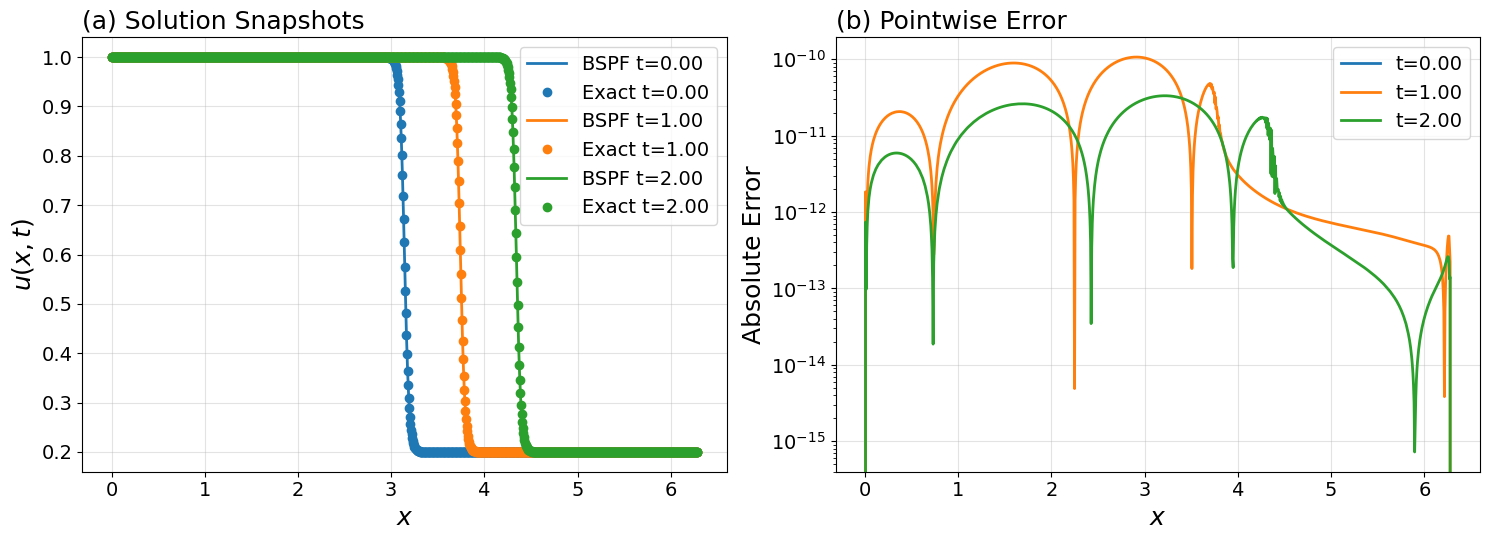

In [6]:
plt.rcParams.update(
    {
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "figure.titlesize": 18,
        "axes.grid": True,
        "grid.alpha": 0.35,
    }
)

sample_times = np.array([0.0, 1.0, final_time])
sample_indices = [int(np.abs(t - ts).argmin()) for ts in sample_times]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

ax = axes[0]
for color, idx in zip(default_colors, sample_indices):
    ax.plot(x, U[idx], "-", color=color, linewidth=2.0, label=f"BSPF t={t[idx]:.2f}")
    ax.plot(x, u_exact[idx], "o", color=color, linewidth=1.8, label=f"Exact t={t[idx]:.2f}")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x,t)$")
ax.set_title("(a) Solution Snapshots", loc="left")
ax.legend(loc="best")

ax = axes[1]
for color, idx in zip(default_colors, sample_indices):
    ax.semilogy(x, np.abs(U[idx] - u_exact[idx]), "-", color=color, linewidth=2.0, label=f"t={t[idx]:.2f}")
ax.set_xlabel("$x$")
ax.set_ylabel("Absolute Error")
ax.set_title("(b) Pointwise Error", loc="left")
ax.legend(loc="best")

fig.tight_layout()
plt.show()